# Note Book structure

1. Setup
2. Load Dataset
3. Train/Test Split
4. Baseline Model (All Features)
5. Univariate Feature Model
6. Random Forest Feature Model
7. RFE Feature Model
8. Performance Comparison
9. Final Observations

In [1]:
import os
import sys

sys.path.append(os.path.abspath(".."))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from src.data_loader import load_data
from src.utils import split_data, apply_feature_selector, get_feature_names

from src.feature_selection import (
    select_univariate,
    select_rf_importance,
    select_rfe
)

from src.models import train_svm, train_logistic_regression
from src.evaluation import evaluate_model

In [4]:
X, y, feature_names, target_names = load_data()

print("Features:", feature_names)
print("Classes:", target_names)

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']


In [9]:
X_train, X_test, y_train, y_test = split_data(X, y)

# Baseline Model (All Features)

## SVM

In [10]:
svm_model = train_svm(X_train, y_train)

svm_results = evaluate_model(svm_model, X_test, y_test)

svm_results["metrics"]

{'accuracy': 1.0, 'precision_macro': 1.0, 'recall_macro': 1.0, 'f1_macro': 1.0}

## Logistic Regression

In [8]:
lr_model = train_logistic_regression(X_train, y_train)

lr_results = evaluate_model(lr_model, X_test, y_test)

lr_results["metrics"]

{'accuracy': 0.9666666666666667,
 'precision_macro': 0.9696969696969697,
 'recall_macro': 0.9666666666666667,
 'f1_macro': 0.9665831244778612}


# Univariate Feature Model

In [12]:
selector_uni, indices_uni, scores = select_univariate(X_train, y_train, k=2)

X_train_uni, X_test_uni = apply_feature_selector(selector_uni, X_train, X_test)

selected_uni = get_feature_names(indices_uni, feature_names)

selected_uni

['petal length (cm)', 'petal width (cm)']

## svm

In [13]:
svm_uni = train_svm(X_train_uni, y_train)

svm_uni_results = evaluate_model(svm_uni, X_test_uni, y_test)

## Logistic Regression

In [14]:
lr_uni = train_logistic_regression(X_train_uni, y_train)

lr_uni_results = evaluate_model(lr_uni, X_test_uni, y_test)

# Random Forest Feature Model

In [15]:
rf_model, importances, ranked_indices = select_rf_importance(X_train, y_train)

top_features = ranked_indices[:2]

top_features

array([2, 3])

In [16]:
X_train_rf = X_train[:, top_features]
X_test_rf = X_test[:, top_features]

#### train models 

In [17]:
svm_rf = train_svm(X_train_rf, y_train)
svm_rf_results = evaluate_model(svm_rf, X_test_rf, y_test)

lr_rf = train_logistic_regression(X_train_rf, y_train)
lr_rf_results = evaluate_model(lr_rf, X_test_rf, y_test)

# RFE Feature Model

In [18]:
selector_rfe, indices_rfe, ranking = select_rfe(X_train, y_train, n_features=2)

X_train_rfe, X_test_rfe = apply_feature_selector(selector_rfe, X_train, X_test)

selected_rfe = get_feature_names(indices_rfe, feature_names)

selected_rfe

['petal length (cm)', 'petal width (cm)']

### train models

In [19]:
svm_rfe = train_svm(X_train_rfe, y_train)
svm_rfe_results = evaluate_model(svm_rfe, X_test_rfe, y_test)

lr_rfe = train_logistic_regression(X_train_rfe, y_train)
lr_rfe_results = evaluate_model(lr_rfe, X_test_rfe, y_test)

# Performance Comparison Table

In [20]:
results = pd.DataFrame({
    "Method": [
        "Baseline",
        "Univariate",
        "Random Forest",
        "RFE"
    ],
    
    "SVM Accuracy": [
        svm_results["metrics"]["accuracy"],
        svm_uni_results["metrics"]["accuracy"],
        svm_rf_results["metrics"]["accuracy"],
        svm_rfe_results["metrics"]["accuracy"]
    ],
    
    "Logistic Regression Accuracy": [
        lr_results["metrics"]["accuracy"],
        lr_uni_results["metrics"]["accuracy"],
        lr_rf_results["metrics"]["accuracy"],
        lr_rfe_results["metrics"]["accuracy"]
    ]
})

results

,Method,SVM Accuracy,Logistic Regression Accuracy
0,Baseline,1.000000,0.966667
1,Univariate,0.966667,0.966667
2,Random Forest,0.966667,0.966667
3,RFE,0.966667,0.966667


# Visualization

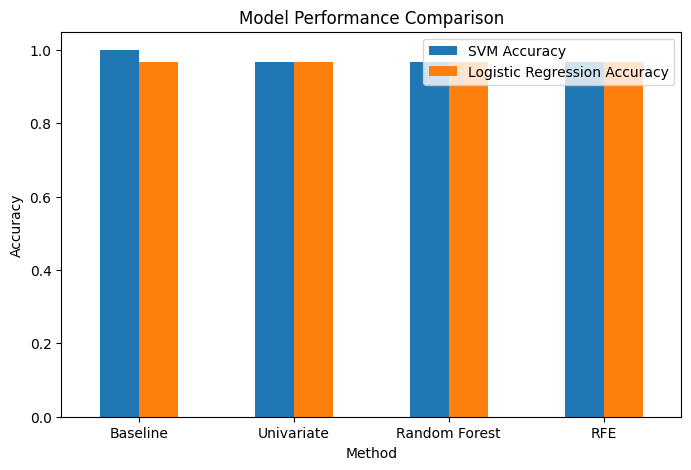

In [21]:
results.set_index("Method").plot(kind="bar", figsize=(8,5))

plt.title("Model Performance Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)

plt.show()

# Observations

<div style="border-left:4px solid #FF9800;padding:10px;background:#f9f9f9;">
<b>Model Comparison Observations</b>

<ul>
<li>Using selected features often maintains similar accuracy compared to using all features.</li>
<li>Petal length and petal width contain most of the discriminative information.</li>
<li>Feature selection reduces dimensionality without significantly degrading model performance.</li>
<li>SVM and Logistic Regression perform similarly on this dataset.</li>
</ul>

</div>